# Healthcare Data Analysis Project

## Objective
The objective of this project is to analyze a healthcare dataset using Python and Pandas, perform Exploratory Data Analysis (EDA), generate insights, and prepare the cleaned dataset for visualization in Power BI.

## Import Libraries

In [2]:
# Import the Pandas library for data manipulation and analysis
import pandas as pd

## Load Dataset

In [3]:
# Load the healthcare dataset into a Pandas DataFrame
df=pd.read_csv("healthcare_dataset.csv")

## 1. Data Understanding
The purpose of this section is to gain an initial understanding of the dataset by examining its structure, dimensions, column names, and data types. This helps identify any potential data quality issues and provides a foundation for the data cleaning and exploratory analysis performed in the subsequent sections.

In [4]:
# Display the first five rows of the dataset
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
# Check the number of rows and columns
df.shape

(55500, 15)

In [6]:
# Display all column names
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='str')

In [7]:
# Display data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


## Observation

The dataset contains **54,966 patient records** and **15 variables** covering patient demographics, hospital admissions, medical conditions, billing information, medications, and test results.

The dataset contains a combination of numerical, categorical, and date variables. No missing values were identified, indicating that the dataset is complete and ready for further data cleaning and preparation. Date columns will be converted to the appropriate datetime format in the next section to support time-based analysis.

## 2. Data Cleaning & Preparation

Prepare the dataset for analysis by checking data quality, removing duplicate records, converting date columns to the appropriate format, and creating a new feature to measure the length of hospital stay.

In [8]:
# Check for missing values
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [9]:
# Count duplicate records
df.duplicated().sum()

np.int64(534)

In [10]:
# Remove duplicate records
df = df.drop_duplicates()

In [11]:
# Verify no duplicate records remain
df.duplicated().sum()

np.int64(0)

In [12]:
# Convert date columns to datetime format
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

In [13]:
# Verify updated data types
df.info()

<class 'pandas.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  str           
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  str           
 3   Blood Type          54966 non-null  str           
 4   Medical Condition   54966 non-null  str           
 5   Date of Admission   54966 non-null  datetime64[us]
 6   Doctor              54966 non-null  str           
 7   Hospital            54966 non-null  str           
 8   Insurance Provider  54966 non-null  str           
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  str           
 12  Discharge Date      54966 non-null  datetime64[us]
 13  Medication          54966 non-null  str           
 14  Test R

### Feature Engineering: Create Length of Stay (in days)

In [14]:
# Feature Engineering: Create Length of Stay (in days)
df["Length of Stay"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

In [15]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


## Observation

The dataset contained no missing values, indicating complete records across all variables. A total of **534 duplicate records** were identified and removed, resulting in **54,966 unique patient records** for analysis.

The admission and discharge date columns were successfully converted to the datetime format, enabling accurate date calculations. As part of feature engineering, a new variable, **Length of Stay**, was created to represent the duration of each patient's hospital stay in days. This feature will be used in subsequent analyses to explore hospital stay patterns and trends.

## 3. Exploratory Data Analysis (EDA)

Explore the cleaned dataset to understand patient demographics, admission characteristics, hospital stay patterns, billing information, and temporal trends. The analyses in this section aim to identify meaningful patterns and insights that support data-driven decision-making.

### 3.1 Patient Demographics

Explore the demographic characteristics of patients, including age, gender, and blood type, to understand the composition of the patient population.

In [16]:
import matplotlib.pyplot as plt

In [17]:
# Display summary statistics for patient age
df["Age"].describe()

count    54966.000000
mean        51.535185
std         19.605661
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

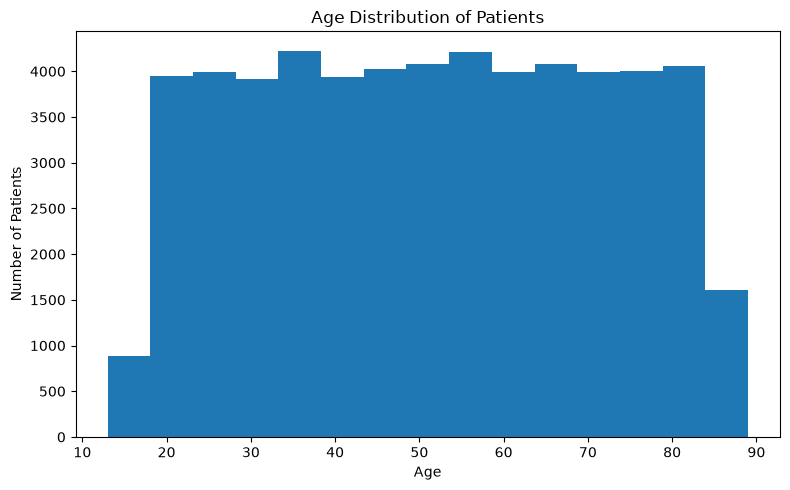

In [18]:
# Visualise the age distribution
# Create a histogram
plt.figure(figsize=(8, 5))
df["Age"].plot(kind="hist", bins=15)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [19]:
# Count the number of patients by gender
df["Gender"].value_counts()

Gender
Male      27496
Female    27470
Name: count, dtype: int64

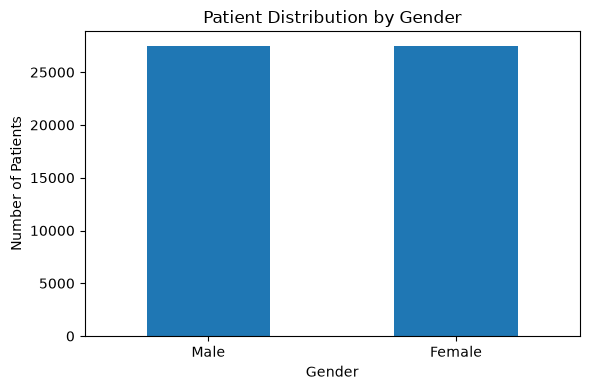

In [20]:
# Visualise the gender distribution
# Create a bar chart
plt.figure(figsize=(6, 4))
df["Gender"].value_counts().plot(kind="bar")

plt.title("Patient Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
# Count the number of patients by blood type
df["Blood Type"].value_counts()

Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64

## Observation

The patient population has a mean age of approximately **51.5 years**, with ages ranging from **13 to 89 years**, indicating a broad age distribution.

The gender distribution is almost perfectly balanced, with **27,496 male** and **27,470 female** patients.

All eight blood groups are represented in the dataset, with only minor differences in their frequencies, indicating a relatively balanced distribution across blood types.

## 3.2 Medical Profile

Explore the distribution of medical conditions, prescribed medications, and test results to understand the clinical characteristics of the patient population.

In [22]:
# Count patients by medical condition
medical_condition_counts = df["Medical Condition"].value_counts()

medical_condition_counts

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

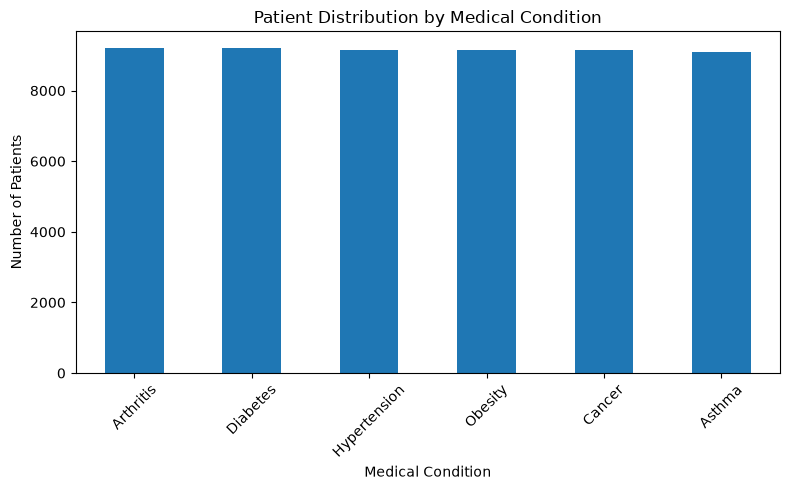

In [23]:
# Visualise the distribution of medical conditions
plt.figure(figsize=(8, 5))
medical_condition_counts.plot(kind="bar")

plt.title("Patient Distribution by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Count patients by medication
df["Medication"].value_counts()

Medication
Lipitor        11038
Ibuprofen      11023
Aspirin        10984
Paracetamol    10965
Penicillin     10956
Name: count, dtype: int64

In [25]:
# Count patients by test result
df["Test Results"].value_counts()

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64

## Observation

The distribution of medical conditions is relatively balanced across the dataset, with **Arthritis (9,218 patients)** being the most common condition and **Asthma (9,095 patients)** the least common. The small differences in patient counts indicate that no single condition dominates the dataset.

Similarly, medication usage is evenly distributed, with **Lipitor** prescribed most frequently (11,038 patients) and **Penicillin** prescribed least frequently (10,956 patients). This suggests that the prescribed medications are well represented across the patient population.

Test results are also evenly distributed, with **Abnormal** results (18,437 patients), **Normal** results (18,331 patients), and **Inconclusive** results (18,198 patients) occurring in similar proportions. Overall, the balanced distribution of medical conditions, medications, and test results makes the dataset suitable for comparative analysis without significant class imbalance.

## 3.3 Admission Profile

Examine how patients were admitted to the hospital and identify the distribution of admission types.

In [26]:
df["Admission Type"].value_counts()

Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

## Observation

The dataset includes three admission types: **Elective**, **Urgent**, and **Emergency**. Their patient counts are relatively similar, with Elective admissions being slightly more common. The balanced distribution suggests that all admission categories are well represented, allowing meaningful comparisons in later analyses.

## 3.4 Insurance Provider Analysis

Explore the distribution of insurance providers among patients.

In [27]:
df["Insurance Provider"].value_counts()

Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64

## Observation

The five insurance providers are represented fairly evenly across the dataset, with only minor differences in patient counts. No single provider dominates the dataset, indicating balanced insurance coverage among the patient population.

## 3.5 Billing Analysis

Analyse the distribution of billing amounts and identify any notable patterns or anomalies in the dataset.

In [28]:
# Calculate summary statistics for billing amount
df["Billing Amount"].describe()

count    54966.000000
mean     25544.306284
std      14208.409711
min      -2008.492140
25%      13243.718641
50%      25542.749145
75%      37819.858159
max      52764.276736
Name: Billing Amount, dtype: float64

In [29]:
# Count the number of negative billing amounts
(df["Billing Amount"] < 0).sum()

np.int64(106)

In [30]:
# Calculate average billing amount by medical condition
df.groupby("Medical Condition")["Billing Amount"].mean().sort_values(ascending=False)

Medical Condition
Obesity         25804.361902
Diabetes        25660.478635
Asthma          25633.461696
Arthritis       25511.783246
Hypertension    25503.058720
Cancer          25152.322947
Name: Billing Amount, dtype: float64

## Observation

The dataset contains **54,966** billing records, with an average billing amount of **25,544.31**. Billing amounts range from **-2,008.49** to **52,764.28**, and the median (**25,542.75**) is very close to the mean, indicating a relatively balanced distribution. However, the billing amounts show considerable variation, with a standard deviation of **14,208.41**. The dataset also contains **106 negative billing amounts** (approximately **0.19%** of records), which may represent refunds, billing adjustments, insurance reimbursements, or data entry errors and should be investigated as part of a data quality assessment.

## 3.6 Length of Stay Analysis

Analyse the distribution of patients' length of stay and compare the average duration across different admission types and medical conditions.

In [31]:
# Calculate summary statistics for length of stay
df["Length of Stay"].describe()

count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

In [32]:
# Count patients by length of stay
df["Length of Stay"].value_counts().sort_index()

Length of Stay
1     1808
2     1830
3     1828
4     1848
5     1819
6     1889
7     1864
8     1807
9     1856
10    1788
11    1872
12    1823
13    1845
14    1888
15    1771
16    1745
17    1793
18    1798
19    1866
20    1893
21    1943
22    1767
23    1845
24    1737
25    1850
26    1800
27    1862
28    1833
29    1844
30    1854
Name: count, dtype: int64

In [33]:
# Calculate average length of stay by admission type
df.groupby("Admission Type")["Length of Stay"].mean().sort_values(ascending=False)

Admission Type
Emergency    15.584134
Elective     15.511178
Urgent       15.403839
Name: Length of Stay, dtype: float64

In [34]:
# Calculate average length of stay by medical condition
df.groupby("Medical Condition")["Length of Stay"].mean().sort_values(ascending=False)

Medical Condition
Asthma          15.677295
Arthritis       15.504231
Cancer          15.501204
Obesity         15.447627
Hypertension    15.436236
Diabetes        15.430664
Name: Length of Stay, dtype: float64

## Observation

Patients stayed in the hospital for an average of **15.5 days**, with most stays ranging from **8 to 23 days**. The distribution of length of stay is relatively consistent across the dataset. Average stay duration varies only slightly between admission types and medical conditions, indicating no substantial differences among these groups.

## 3.7 Time-Based Analysis

Analyse patient admissions over time to identify yearly and seasonal trends in hospital admissions.

In [35]:
# Create a new column for Admission Year
df["Admission Year"] = df["Date of Admission"].dt.year

In [36]:
# Count patient admissions by year
df["Admission Year"].value_counts().sort_index()

Admission Year
2019     7300
2020    11172
2021    10816
2022    10915
2023    10936
2024     3827
Name: count, dtype: int64

In [37]:
# Create a new column for admission season
df["Season"] = df["Date of Admission"].dt.month.map({
    12: "Summer", 1: "Summer", 2: "Summer",
    3: "Autumn", 4: "Autumn", 5: "Autumn",
    6: "Winter", 7: "Winter", 8: "Winter",
    9: "Spring", 10: "Spring", 11: "Spring"
})

In [38]:
# Count patient admissions by season
df["Season"].value_counts().reindex([
    "Summer",
    "Autumn",
    "Winter",
    "Spring"
])

Season
Summer    13482
Autumn    13655
Winter    14200
Spring    13629
Name: count, dtype: int64

## Observation

Patient admissions are distributed across multiple years, providing a broad time span for analysis. Seasonal admissions are relatively balanced, with no strong seasonal peaks observed. Overall, the dataset does not indicate significant yearly or seasonal fluctuations in hospital admissions.

In [39]:
df.to_csv("healthcare_cleaned.csv", index=False)

## 4. Key Findings

Summarise the key insights identified during the exploratory data analysis.

- The dataset contains **54,966** patient records after removing duplicate entries, with no missing values remaining after data preparation.

- The patient population is well balanced across gender, blood types, medical conditions, admission types, and insurance providers, with no category significantly dominating the dataset.

- The average hospital stay is approximately **15.5 days**, with only minor differences observed across admission types and medical conditions.

- The average billing amount is **25,544.31**, with **106 negative billing records** identified. These may represent refunds, billing adjustments, insurance reimbursements, or data quality issues requiring further investigation.

- Patient admissions are distributed across multiple years and remain relatively consistent across all four seasons, indicating no significant temporal or seasonal fluctuations in hospital admissions.

## 5. Conclusion

This exploratory data analysis provided an overview of patient demographics, medical conditions, hospital admissions, length of stay, billing amounts, and time-based admission patterns. The analysis found balanced distributions across most variables, consistent hospital stay durations, and stable admission trends over time. A small number of negative billing records were identified as potential data quality issues that warrant further investigation. Overall, the dataset is well structured and suitable for exploratory analysis, healthcare reporting, operational decision-making, and as a foundation for future predictive modelling.